## Pima Indians Diabetes - EDA & Prediction

This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, roc_auc_score

In [3]:
db_data = pd.read_csv('./diabetes.csv')

#### About the data

In [4]:
db_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
db_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
db_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


The dataset contains info about 768 persons. There are no nulls in the data.

Attribute Information:

- Number of times pregnant

- Plasma glucose concentration a 2 hours in an oral glucose tolerance test

- Diastolic blood pressure (mm Hg)

- Triceps skin fold thickness (mm)

- 2-Hour serum insulin (mu U/ml)

- Body mass index (weight in kg/(height in m)^2)

- Diabetes pedigree function scores likelihood of diabetes based on family history

- Age (years)

- Class variable (0 or 1)

#### Data Visualization

*Basic Distributions of Each Feature*

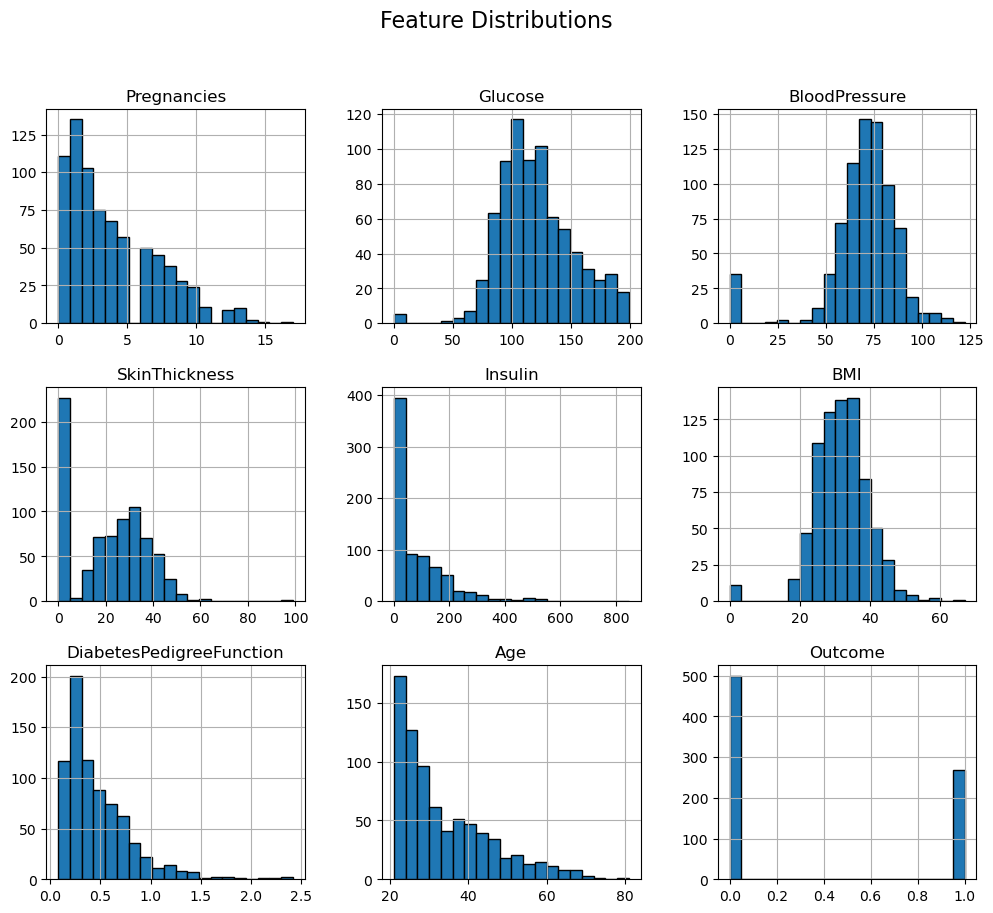

In [7]:
db_data.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

We observe that only Glucose and Blood Pressure are normally distributed rest others are skewed and have outliers

*Outcome Class Distribution*

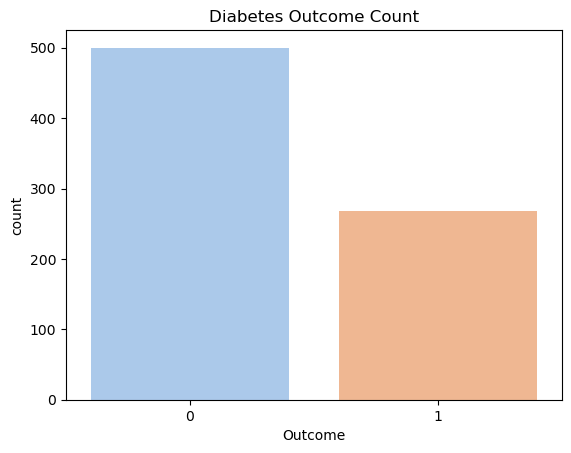

In [8]:
sns.countplot(data=db_data, x='Outcome', palette='pastel', hue='Outcome', legend=False)
plt.title("Diabetes Outcome Count")
plt.show()

We observe that number of people who do not have diabetes is far more than people who do which indicates that our data is imbalanced

#### Data Cleaning

In [9]:
# Check missing values
print("Missing values per column:\n", db_data.isnull().sum())

Missing values per column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


It isn't medically possible for some data record to have 0 value such as Blood Pressure or Glucose levels, so we'll check such columns.

In [10]:
# Checking zeros for suspicious columns
cols_suspicious = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_suspicious:
    zero_count = (db_data[col] == 0).sum()
    print(f"{col}: {zero_count}")

Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


Replacing 0 with NaN for these features

In [11]:
db_data[cols_suspicious] = db_data[cols_suspicious].replace(0,np.nan)
db_data.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [12]:
print(db_data.groupby('Outcome')['Glucose'].median())
print(db_data.groupby('Outcome')['BloodPressure'].median())
print(db_data.groupby('Outcome')['SkinThickness'].median())
print(db_data.groupby('Outcome')['Insulin'].median())
print(db_data.groupby('Outcome')['BMI'].median())

Outcome
0    107.0
1    140.0
Name: Glucose, dtype: float64
Outcome
0    70.0
1    74.5
Name: BloodPressure, dtype: float64
Outcome
0    27.0
1    32.0
Name: SkinThickness, dtype: float64
Outcome
0    102.5
1    169.5
Name: Insulin, dtype: float64
Outcome
0    30.1
1    34.3
Name: BMI, dtype: float64


We can see that the median values for the suspicious columns vary significantly between the two outcomes so it's better to impute values based on median of target variable. This is more accurate because people with diabetes often have systematically higher glucose, insulin, BMI, etc. than those without.

In [13]:
for col in cols_suspicious:
    db_data[col].fillna(db_data.groupby('Outcome')[col].transform('median'),inplace=True)

/var/folders/gg/d8pdbkqd27j216j2xdnz6_f00000gn/T/ipykernel_24687/3041510951.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db_data[col].fillna(db_data.groupby('Outcome')[col].transform('median'),inplace=True)


#### Feature Relationships

/var/folders/gg/d8pdbkqd27j216j2xdnz6_f00000gn/T/ipykernel_24687/783474531.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_diabetes = db_data.groupby('AgeGroup')['Outcome'].mean()


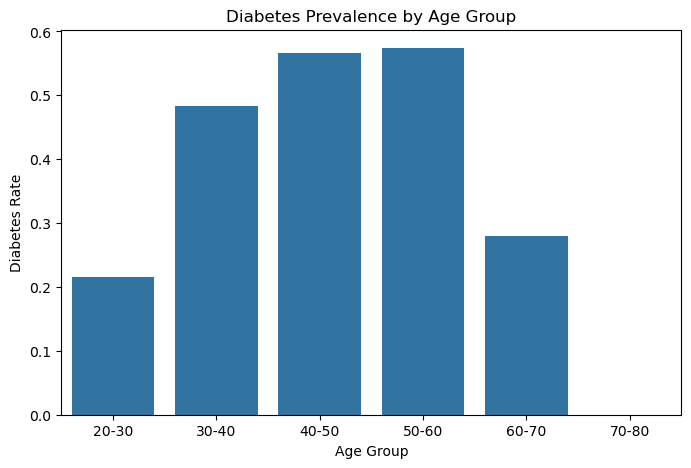

In [48]:
db_data['AgeGroup'] = pd.cut(
    db_data['Age'],
    bins=[20,30,40,50,60,70,80],
    labels=['20-30','30-40','40-50','50-60','60-70','70-80']
)

age_diabetes = db_data.groupby('AgeGroup')['Outcome'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=age_diabetes.index, y=age_diabetes.values)
plt.ylabel("Diabetes Rate")
plt.xlabel("Age Group")
plt.title("Diabetes Prevalence by Age Group")
plt.show()

Diabetes prevalence increases with age rising sharply after the 30–40 age group and peaking around ages 40–60. This suggests age is an important risk factor and aligns with medical understanding that diabetes risk increases with aging.

/var/folders/gg/d8pdbkqd27j216j2xdnz6_f00000gn/T/ipykernel_24687/731694720.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_diabetes = db_data.groupby('BMI_Category')['Outcome'].mean()


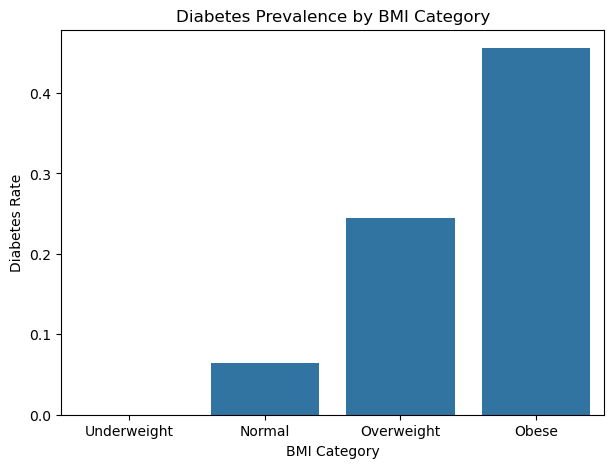

In [50]:
db_data['BMI_Category'] = pd.cut(
    db_data['BMI'],
    bins=[0,18.5,25,30,100],
    labels=['Underweight','Normal','Overweight','Obese']
)

bmi_diabetes = db_data.groupby('BMI_Category')['Outcome'].mean()

plt.figure(figsize=(7,5))
sns.barplot(x=bmi_diabetes.index, y=bmi_diabetes.values)

plt.ylabel("Diabetes Rate")
plt.xlabel("BMI Category")
plt.title("Diabetes Prevalence by BMI Category")

plt.show()

Diabetes prevalence increases significantly across BMI categories with the highest rates observed among individuals classified as obese. This indicates a strong association between higher BMI and increased diabetes risk.

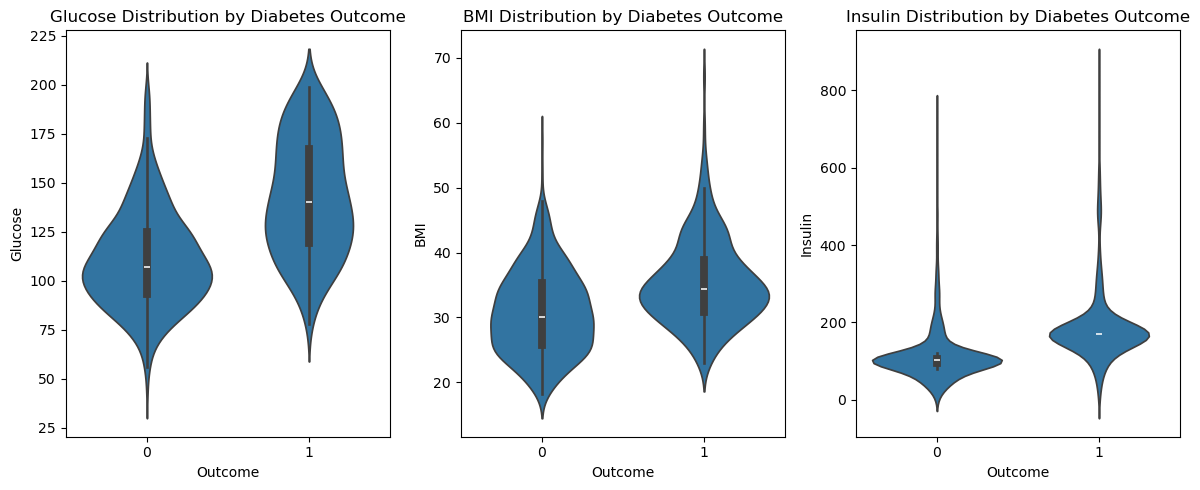

In [51]:
plt.figure(figsize=(12,5))

features = ['Glucose','BMI','Insulin']

for i, feature in enumerate(features,1):
    
    plt.subplot(1,3,i)
    
    sns.violinplot(
        x='Outcome',
        y=feature,
        data=db_data
    )
    
    plt.title(f"{feature} Distribution by Diabetes Outcome")

plt.tight_layout()
plt.show()

Individuals with diabetes show noticeably higher glucose levels compared to non-diabetic individuals highlighting glucose as a strong predictor. BMI and insulin levels also tend to be higher and more variable among diabetic patients suggesting metabolic differences between the two groups.

Correlation Heatmap

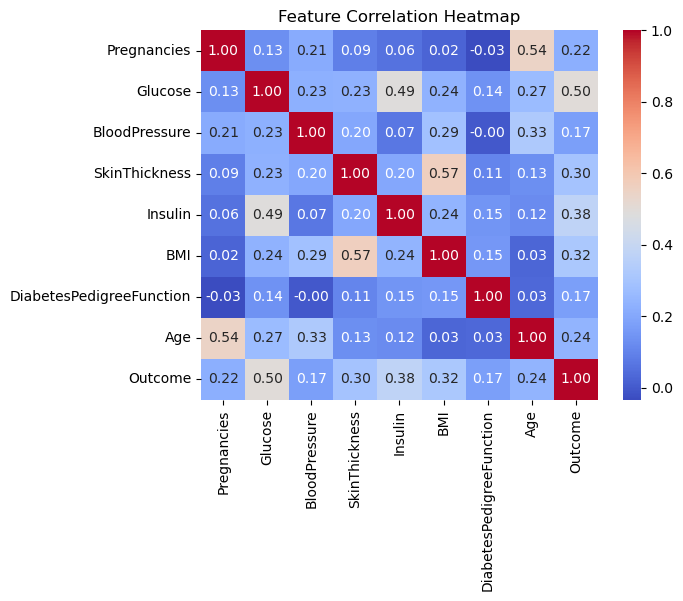

In [18]:
sns.heatmap(db_data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation analysis shows that Glucose is the strongest predictor of diabetes, with a moderate-to-strong positive relationship (0.50) with the outcome. Insulin, BMI and SkinThickness have moderate correlations (0.30–0.38), indicating they contribute meaningfully to risk prediction. Age and other features show weaker correlations, suggesting a smaller but potentially complementary role in modeling.

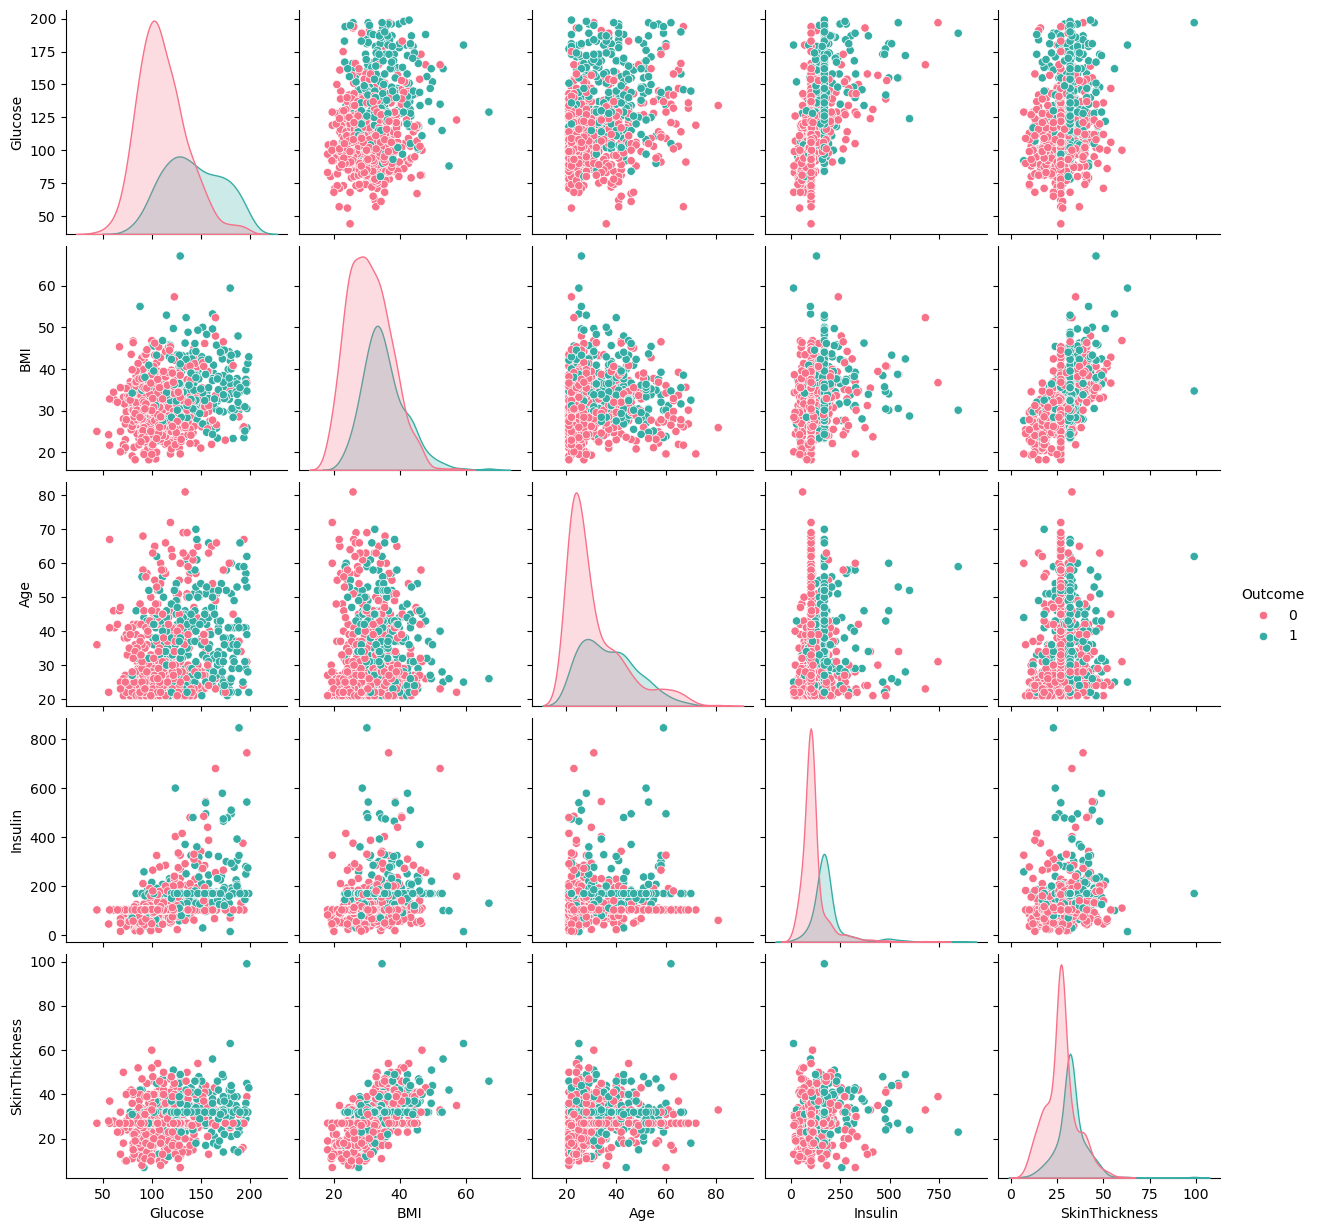

In [32]:
sns.pairplot(db_data, vars=['Glucose', 'BMI', 'Age', 'Insulin', 'SkinThickness'], hue='Outcome', palette='husl')
plt.show()

**Looking at the uni-variate pairplots**

Glucose

- Diabetic patients (Outcome = 1, green) generally have higher glucose values than non-diabetic patients

- Separation between the two classes makes Glucose the strongest predictor

BMI

- Diabetic patients tend to have slightly higher BMI values but there is more overlap with non-diabetics than Glucose

Insulin

- Insulin values are scattered with some overlap, but diabetic patients appear more concentrated at higher insulin levels

Age

- Age shows the least separation between classes as both diabetic and non-diabetic patients span similar age ranges



Summary - Glucose is the clearest indicator of diabetes, followed by moderate contributions from BMI and Insulin. Age shows minimal direct influence.

**Looking at the multi-variate pairplots**


Insulin vs Glucose

- Moderate positive relationship but with outliers and wide spread

- Higher glucose tends to require higher insulin but variability is large

Glucose vs BMI

- Patients with both high BMI and high glucose are more likely diabetic

- Useful because it shows the interaction of obesity and glucose intolerance, clear separation compared to non-diabetics

## Modeling

In [20]:
X = db_data.drop('Outcome',axis=1)
y = db_data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


#####

In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Logistic Regression

In [23]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print(classification_report(y_test, y_pred))
print("\n F1:\n",f1_score(y_test,y_pred))
print("\n Precision score is:\n",precision_score(y_test,y_pred))
print("\n Recall score is:\n",recall_score(y_test,y_pred))
print("\n ROC-AUC:\n", roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154


 F1:
 0.5714285714285714

 Precision score is:
 0.5882352941176471

 Recall score is:
 0.5555555555555556

 ROC-AUC:
 0.6727777777777778


The model achieved an **overall accuracy of 71%** on the test set. Performance metrics show that the model predicts the non-diabetic class (Outcome = 0) reasonably well, with an **F1-score of 0.78**, while performance for the diabetic class (Outcome = 1) is noticeably lower, with an **F1-score of 0.57**.

This indicates that the model struggles to correctly identify diabetic patients, reflected in a **recall of 0.56** for the positive class. In a healthcare context, this is important because lower recall means a higher number of false negatives (diabetic patients predicted as non-diabetic).

The **ROC-AUC score of 0.67** suggests moderate discriminative ability but indicates that there is significant room for improvement. These results have helped establish a baseline performance.

#### K-Fold Cross Validation

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [28]:
log_reg = LogisticRegression(max_iter=1000)

# stratified k-fold (10 fold)
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_validate(
    log_reg,
    X,
    y,
    cv=kfold,
    scoring=['accuracy','precision','recall','f1','roc_auc']
)

for metric in scores:
    print(metric, np.mean(scores[metric]))

fit_time 0.009761762619018555
score_time 0.004040050506591797
test_accuracy 0.7720608339029392
test_precision 0.7202646999513659
test_recall 0.5935897435897435
test_f1 0.6441757883540012
test_roc_auc 0.858


To obtain a more robust estimate of model performance, a Stratified 10-Fold Cross Validation approach was used. Stratification ensures that each fold maintains the same class distribution as the original dataset.

The cross-validation results show an average accuracy of **77.2%** and an **F1 score of 0.64**, indicating moderate predictive performance. Precision for the diabetic class is relatively strong at **0.72**, while recall remains lower at **0.59** suggesting that the model still misses a portion of true diabetic cases.

The **ROC-AUC score of 0.858** indicates strong class separation capability, suggesting that the model can effectively distinguish between diabetic and non-diabetic cases, although the classification threshold may limit recall performance.

#### Random Forest Classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

rf_scores = cross_validate(
    rf,
    X,
    y,
    cv=kfold,
    scoring=['accuracy','precision','recall','f1','roc_auc']
)

for metric in rf_scores:
    print(metric, np.mean(rf_scores[metric]))

fit_time 0.21174969673156738
score_time 0.013078927993774414
test_accuracy 0.8815447710184554
test_precision 0.8551869688671934
test_recall 0.8025641025641024
test_f1 0.8241504489663024
test_roc_auc 0.9424786324786325


To capture nonlinear relationships and feature interactions in the dataset, a Random Forest classifier was trained and evaluated using **10-fold Stratified Cross Validation**. This approach ensures that each fold maintains the original class distribution and provides a more robust estimate of model performance.

The Random Forest model significantly outperformed the logistic regression baseline across all evaluation metrics. The model achieved an **average accuracy of 88.2%**, with a **precision of 0.86** and **recall of 0.80** for the diabetic class. The resulting **F1 score of 0.82** indicates strong balance between precision and recall.

Additionally, the model achieved a **ROC-AUC score of 0.94** suggesting excellent ability to distinguish between diabetic and non-diabetic cases. Compared to the earlier logistic regression model (F1 ~ 0.64, ROC-AUC ~ 0.86), Random Forest provides a substantial improvement in predictive performance, particularly in identifying diabetic patients.

This shows the benefit of using ensemble tree-based models for tabular healthcare data as they can capture nonlinear patterns and feature interactions that linear models may miss.

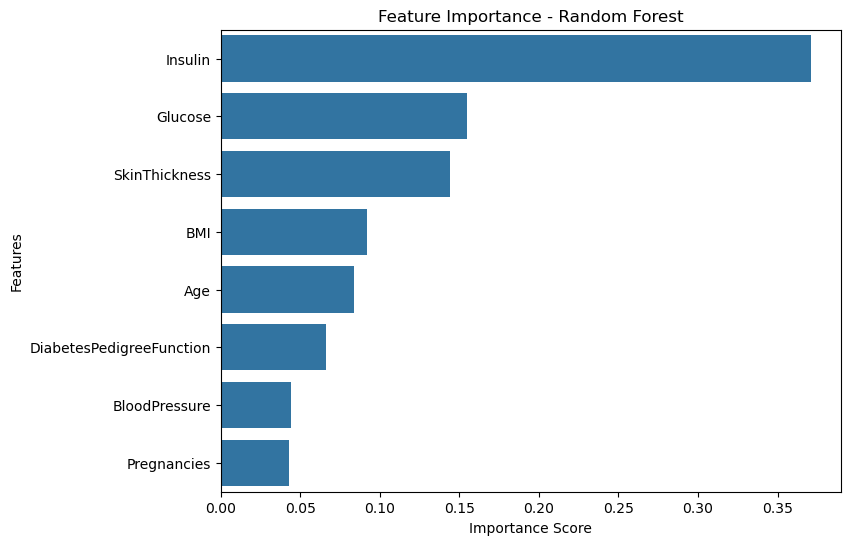

In [31]:
rf.fit(X, y)

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

To better understand which variables contribute most to diabetes prediction feature importance scores were extracted from the trained Random Forest model. Tree-based models naturally estimate the importance of each feature based on how much it reduces impurity across decision splits.

The resulting feature importance scores indicate which variables the model relies on most when making predictions. This helps provide interpretability to the model and allows us to identify the key medical indicators associated with diabetes risk.

The top contributing features identified by the model include **Insulin, Glucose, Skin Thickness, BMI and Age**.

#### Random Forest with SMOTE (Handling Class Imbalance)

In [34]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=300, random_state=42))
])

scores = cross_validate(
    pipeline,
    X,
    y,
    cv=kfold,
    scoring=['accuracy','precision','recall','f1','roc_auc']
)

for metric in scores:
    print(metric, np.mean(scores[metric]))

fit_time 0.2581611156463623
score_time 0.01332869529724121
test_accuracy 0.8789131920710869
test_precision 0.8176699226699228
test_recall 0.8544159544159543
test_f1 0.8316047119343937
test_roc_auc 0.9414131054131053


To address class imbalance in the dataset Synthetic Minority Oversampling Technique (SMOTE) was applied to generate synthetic samples for the minority class (diabetic patients). This allows the model to learn patterns from a more balanced dataset.

After applying SMOTE the Random Forest model showed an increase in **recall from 0.80 to 0.85** indicating improved ability to correctly identify diabetic patients. While precision decreased slightly the **overall F1 score improved from 0.82 to 0.83**, reflecting a better balance between precision and recall.

The **ROC-AUC score remained stable at approximately 0.94**, suggesting that the model maintains strong class separation ability. These results highlight the benefit of addressing class imbalance when the objective is to improve detection of the minority class particularly in healthcare prediction tasks.

#### XGBoost

In [44]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
    tree_method="hist"
)

xgb_scores = cross_validate(
    xgb,
    X,
    y,
    cv=kfold,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

for metric in xgb_scores:
    print(metric, np.mean(xgb_scores[metric]))

fit_time 0.07485451698303222
score_time 0.005627727508544922
test_accuracy 0.884142173615858
test_precision 0.8421350356567748
test_recall 0.8246438746438747
test_f1 0.8321856795903176
test_roc_auc 0.9485242165242166


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       100
           1       0.82      0.83      0.83        54

    accuracy                           0.88       154
   macro avg       0.86      0.87      0.87       154
weighted avg       0.88      0.88      0.88       154



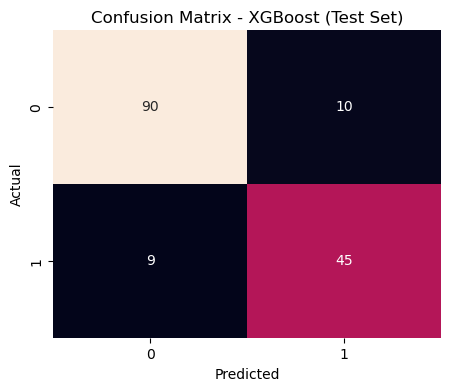

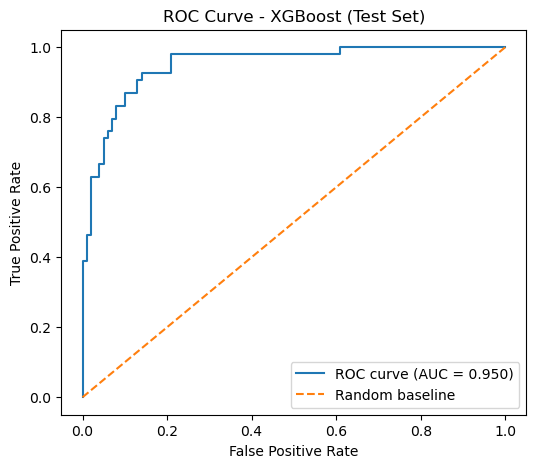

Test ROC-AUC: 0.9500000000000001


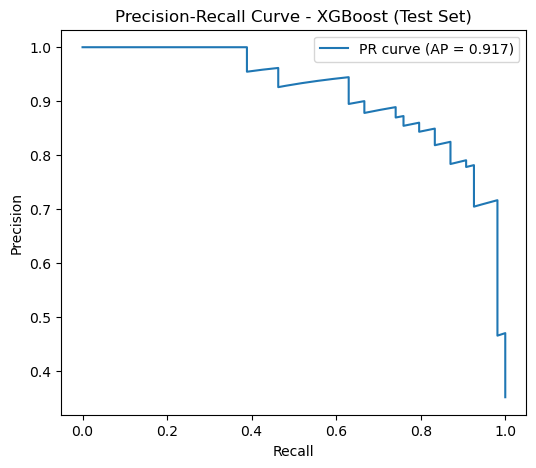

Test Average Precision (AP): 0.9167247305359438


In [47]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
xgb_final = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
    tree_method="hist"
)

xgb_final.fit(X_train, y_train)
y_pred = xgb_final.predict(X_test)
y_proba = xgb_final.predict_proba(X_test)[:, 1]

print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost (Test Set)")
plt.show()

roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (Test Set)")
plt.legend()
plt.show()

print("Test ROC-AUC:", roc_auc)

precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost (Test Set)")
plt.legend()
plt.show()

print("Test Average Precision (AP):", ap)

To further improve predictive performance an XGBoost classifier was trained and evaluated. Gradient boosting models such as XGBoost are well suited for structured tabular datasets because they iteratively build decision trees that correct the errors made by previous trees.

The model was trained on the training dataset and evaluated on a held-out test set to assess generalization performance. The results show strong predictive performance with an **overall accuracy of 88%**. For the diabetic class (Outcome = 1) the model achieved **precision of 0.82**, **recall of 0.83**, and an **F1 score of 0.83** indicating a good balance between identifying true diabetic cases and minimizing false positives.

Additionally the model achieved a **ROC-AUC score of 0.95** showing excellent ability to distinguish between diabetic and non-diabetic patients. The **Average Precision (AP) score of 0.917** further confirms strong performance when evaluating precision-recall tradeoffs in this imbalanced dataset.


### Model Performance Comparison

| Model                 | Accuracy | Precision | Recall   | F1 Score | ROC-AUC  |
| --------------------- | -------- | --------- | -------- | -------- | -------- |
| Logistic Regression   | 0.77     | 0.72      | 0.59     | 0.64     | 0.86     |
| Random Forest         | 0.88     | 0.86      | 0.80     | 0.82     | 0.94     |
| Random Forest + SMOTE | 0.88     | 0.82      | **0.85** | **0.83** | 0.94     |
| XGBoost               | **0.88** | 0.82      | 0.83     | **0.83** | **0.95** |

### Conclusion

Among the evaluated models **tree-based ensemble methods significantly outperform the logistic regression baseline**, highlighting the importance of capturing nonlinear relationships in the dataset.

Both **Random Forest + SMOTE** and **XGBoost** achieve the highest F1 scores (~0.83), indicating strong balance between precision and recall. However **XGBoost achieves the highest ROC-AUC score (0.95)**, demonstrating greater ability to distinguish between diabetic and non-diabetic patients across decision thresholds.

Overall **XGBoost is selected as the final model** due to its strong predictive performance, stability across cross-validation and test evaluation and superior class discrimination capability.
